# PoissonGAM for Precipitation Modeling

Demonstrates Poisson GAMs for wet-day count data. **Poisson**: count data with mean ≈ variance; **Log link**: log(μ) = f(x) → μ = exp(f(x)). Use when: counts, many zeros, mean ≈ var. Avoid for: continuous outcomes, overdispersion (→ NegativeBinomialGAM), or binary (→ LogisticGAM).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dask.dataframe as dd
import warnings
warnings.filterwarnings('ignore')

# SciPy 2.0+ compatibility: .A was removed from sparse matrices; pygam still uses it
import scipy.sparse as sp
if not hasattr(sp.csr_matrix, 'A'):
    sp.csr_matrix.A = property(lambda self: self.toarray())

from pygam import PoissonGAM, s
plt.style.use('seaborn-v0_8')

In [2]:
# Load precipitation data
df = dd.read_parquet("../../../weather_data/stations_weather_with_dist2coast.parquet")
prcp_df = df[df['ELEMENT'] == 'PRCP'].compute()
station_counts = prcp_df.groupby('ID')['year'].nunique().sort_values(ascending=False)
selected_station = station_counts.index[0]
station_data = prcp_df[prcp_df['ID'] == selected_station].copy()
print(f"Station {selected_station}: {station_data['name'].iloc[0]}, {len(station_data)} years")

Station USW00023062: DENVER-STAPLETON, 73 years


### Exploratory Data: Distribution and Seasonality

**Left:** Histogram of non-zero precipitation amounts (log scale). Right-skewed, many small values—typical for precipitation. **Right:** Daily precipitation for one sample year across day of year, showing seasonal variation.

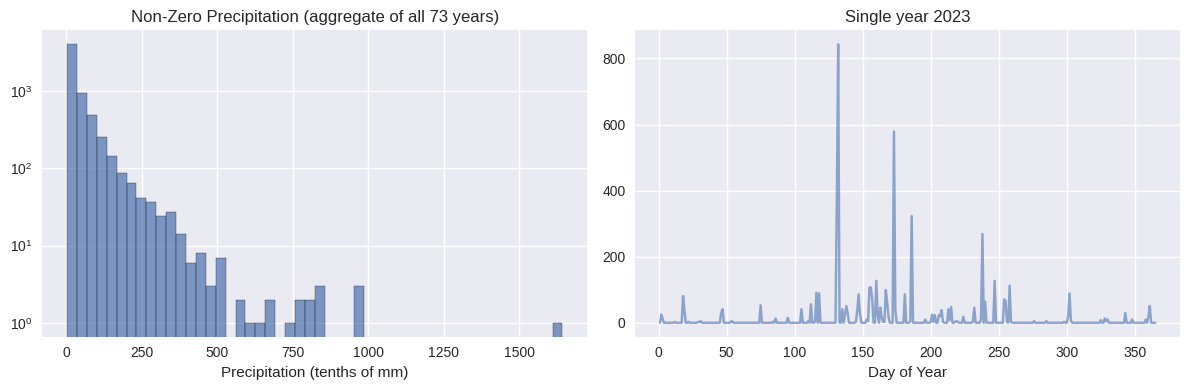

In [3]:
# Reshape to daily format and plot EDA
day_cols = sorted([c for c in station_data.columns if c.startswith('day_')], key=lambda x: int(x.split('_')[1]))
daily_data = []
for idx, row in station_data.iterrows():
    for day_idx, day_col in enumerate(day_cols, start=1):
        v = row[day_col]
        if pd.notna(v):
            daily_data.append({'year': row['year'], 'day_of_year': day_idx, 'precipitation': v})
daily_df = pd.DataFrame(daily_data)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(daily_df[daily_df['precipitation'] > 0]['precipitation'], bins=50, edgecolor='k', alpha=0.7)
axes[0].set_xlabel('Precipitation (tenths of mm)')
axes[0].set_yscale('log')
axes[0].set_title(f'Non-Zero Precipitation (aggregate of all {len(station_data)} years)')
y0 = daily_df['year'].iloc[0]
yd = daily_df[daily_df['year'] == y0].sort_values('day_of_year')
axes[1].plot(yd['day_of_year'], yd['precipitation'], alpha=0.6)
axes[1].set_xlabel('Day of Year')
axes[1].set_title(f'Single year {y0}')
plt.tight_layout()
plt.show()

## Data prep: Wet-day counts per period
Model wet-day counts (not amounts) per 2-week period. Check variance ≈ mean before fitting Poisson.

In [4]:
period_length = 14
daily_df['period'] = ((daily_df['day_of_year'] - 1) // period_length) + 1
wet_day_counts = daily_df.groupby(['year', 'period']).apply(lambda x: (x['precipitation'] > 0).sum()).reset_index(name='wet_day_count')

mean_c, var_c = wet_day_counts['wet_day_count'].mean(), wet_day_counts['wet_day_count'].var()
print(f"Mean: {mean_c:.2f}, Variance: {var_c:.2f}, Dispersion: {var_c/mean_c:.2f}")
print("✓ Suitable for Poisson" if var_c/mean_c < 1.5 else "⚠ Consider NegativeBinomial")

wet_day_counts['period_center'] = (wet_day_counts['period'] - 1) * period_length + period_length / 2
wet_day_counts['day_of_year_approx'] = wet_day_counts['period_center']

model_data = {}
for year in wet_day_counts['year'].unique():
    yd = wet_day_counts[wet_day_counts['year'] == year].sort_values('period')
    model_data[year] = {'X': yd[['day_of_year_approx']].values, 'y': yd['wet_day_count'].values}

Mean: 3.18, Variance: 4.88, Dispersion: 1.53
⚠ Consider NegativeBinomial


## Fit PoissonGAM per year
s(0) = smooth spline on day of year; n_splines=12, spline_order=3.

In [5]:
# Fit PoissonGAM for each year (needed for Observed vs Fitted and Year-to-Year)
models = {}
fit_summary = []
for year in model_data:
    X, y = model_data[year]['X'], model_data[year]['y']
    gam = PoissonGAM(s(0, n_splines=12, spline_order=3)).gridsearch(X, y)
    print(f'Year {year}: selected lambda = {gam.lam}')
    models[year] = gam
    yp = gam.predict(X)
    fit_summary.append({'year': year, 'mean_y': y.mean(), 'mean_pred': yp.mean(), 'AIC': gam.statistics_['AIC'], 'deviance': gam.statistics_['deviance']})
fit_summary_df = pd.DataFrame(fit_summary)

all_obs, all_pred = [], []
for yr in model_data:
    Xy = model_data[yr]
    all_obs.extend(Xy['y'])
    all_pred.extend(models[yr].predict(Xy['X']))
all_obs, all_pred = np.array(all_obs), np.array(all_pred)

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--


Year 1950: selected lambda = [[63.0957344480193]]
Year 1951: selected lambda = [[63.0957344480193]]
Year 1952: selected lambda = [[15.848931924611142]]


100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--


Year 1953: selected lambda = [[15.848931924611142]]


100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--


...

Year 2016: selected lambda = [[15.848931924611142]]
Year 2017: selected lambda = [[15.848931924611142]]
Year 2018: selected lambda = [[0.0630957344480193]]
Year 2019: selected lambda = [[63.0957344480193]]


 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--


Year 2020: selected lambda = [[63.0957344480193]]
Year 2022: selected lambda = [[1000.0]]
Year 2023: selected lambda = [[3.981071705534969]]
Year 2024: selected lambda = [[251.18864315095772]]


100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


Year 2025: selected lambda = [[3.981071705534969]]


### Observed vs Fitted: Single Year

Points are observed wet-day counts per 2-week period; the blue curve is the PoissonGAM spline fit. The shaded band is the approximate 95% prediction interval. Peaks and troughs show seasonal wetness.

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


2023 aggregate: selected lambda = [[63.0957344480193]]


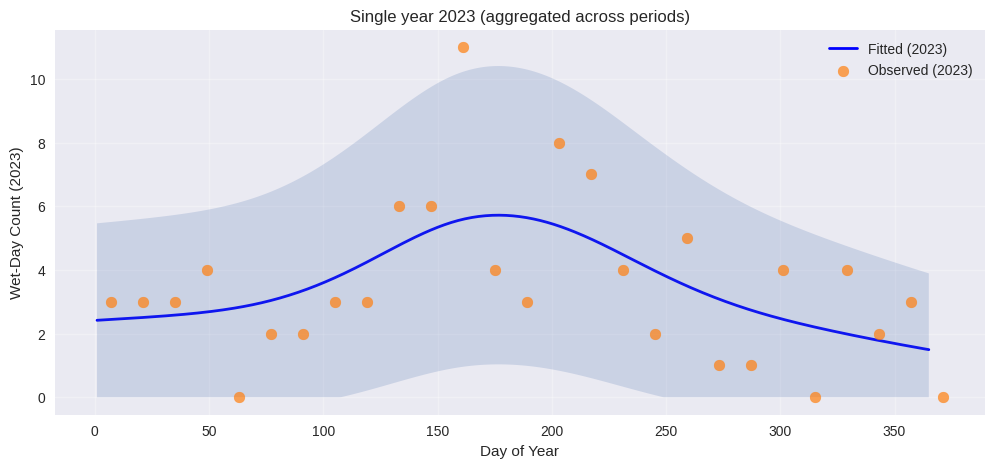

In [6]:
# Observed vs fitted: counts aggregated over 2023 alone

# Aggregate wet day counts and periods for year 2023 only (sum counts per period)
agg_2023 = wet_day_counts.loc[
    wet_day_counts['year'] == 2023
].groupby('period').agg({
    'day_of_year_approx': 'first',   # period center
    'wet_day_count': 'sum'           # sum counts for 2023
}).sort_values('day_of_year_approx')

X_obs_2023 = agg_2023[['day_of_year_approx']].values
y_obs_2023 = agg_2023['wet_day_count'].values

# Fit PoissonGAM to the aggregated data for 2023
from pygam import PoissonGAM, s

gam_agg_2023 = PoissonGAM(s(0)).gridsearch(X_obs_2023, y_obs_2023)
print(f'2023 aggregate: selected lambda = {gam_agg_2023.lam}')
X_smooth_2023 = np.linspace(1, 365, 365).reshape(-1, 1)
y_smooth_2023 = gam_agg_2023.predict(X_smooth_2023)

plt.figure(figsize=(12, 5))
plt.plot(X_smooth_2023, y_smooth_2023, 'b-', lw=2, label='Fitted (2023)', zorder=1)
plt.scatter(X_obs_2023, y_obs_2023, alpha=0.7, s=60, color='tab:orange', label='Observed (2023)', zorder=2)
lb_2023 = np.maximum(0, y_smooth_2023 - 1.96*np.sqrt(y_smooth_2023))
plt.fill_between(X_smooth_2023.flatten(), lb_2023, y_smooth_2023 + 1.96*np.sqrt(y_smooth_2023), alpha=0.2)
plt.xlabel('Day of Year')
plt.ylabel('Wet-Day Count (2023)')
plt.title('Single year 2023 (aggregated across periods)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


2013-2023 aggregate: selected lambda = [[1.0]]


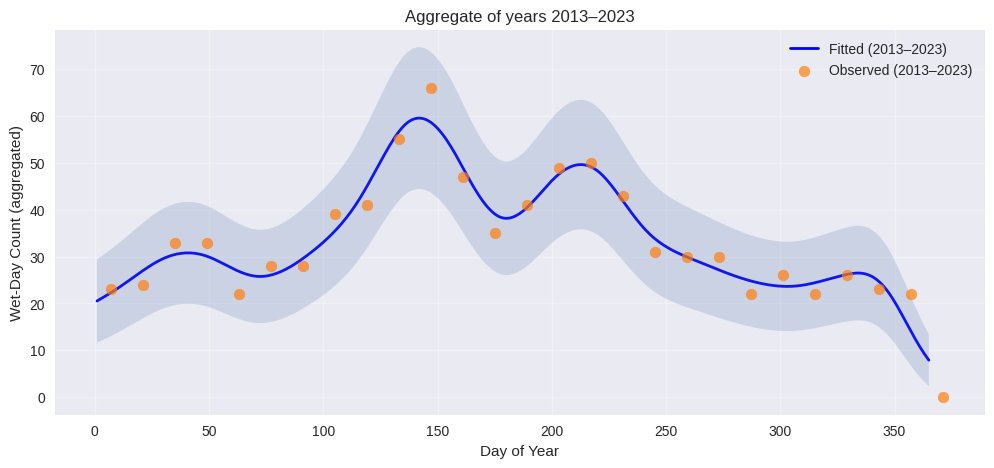

In [7]:
# Observed vs fitted: counts aggregated over 2013-2023

# Aggregate wet day counts and periods over years 2013-2023 (sum counts per period)
agg_years = wet_day_counts.loc[
    wet_day_counts['year'].between(2013, 2023)
].groupby('period').agg({
    'day_of_year_approx': 'first',   # period center
    'wet_day_count': 'sum'           # sum counts across selected years
}).sort_values('day_of_year_approx')

X_obs_period = agg_years[['day_of_year_approx']].values
y_obs_period = agg_years['wet_day_count'].values

# Fit PoissonGAM to the aggregated data (2013-2023)
from pygam import PoissonGAM, s

gam_agg = PoissonGAM(s(0)).gridsearch(X_obs_period, y_obs_period)
print(f'2013-2023 aggregate: selected lambda = {gam_agg.lam}')
X_smooth = np.linspace(1, 365, 365).reshape(-1, 1)
y_smooth = gam_agg.predict(X_smooth)

plt.figure(figsize=(12, 5))
plt.plot(X_smooth, y_smooth, 'b-', lw=2, label='Fitted (2013–2023)', zorder=1)
plt.scatter(X_obs_period, y_obs_period, alpha=0.7, s=60, color='tab:orange', label='Observed (2013–2023)', zorder=2)
lb = np.maximum(0, y_smooth - 1.96*np.sqrt(y_smooth))
plt.fill_between(X_smooth.flatten(), lb, y_smooth + 1.96*np.sqrt(y_smooth), alpha=0.2)
plt.xlabel('Day of Year')
plt.ylabel('Wet-Day Count (aggregated)')
plt.title('Aggregate of years 2013–2023')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


All years aggregate: selected lambda = [[0.015848931924611134]]


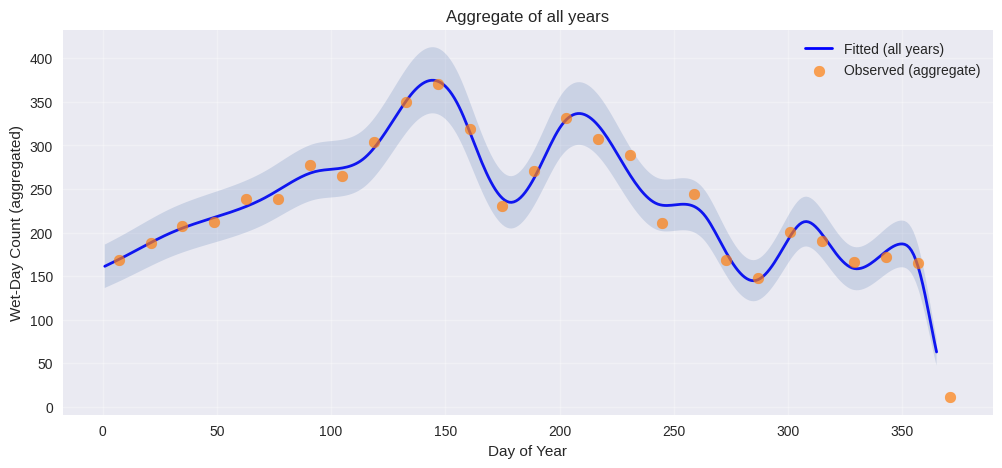

In [8]:
# Observed vs fitted: counts aggregated over all years

# Aggregate wet day counts and periods over all years (sum counts per period)
agg = wet_day_counts.groupby('period').agg({
    'day_of_year_approx': 'first',   # period center
    'wet_day_count': 'sum'           # sum counts across all years
}).sort_values('day_of_year_approx')

X_obs_all = agg[['day_of_year_approx']].values
y_obs_all = agg['wet_day_count'].values

# Fit PoissonGAM to the aggregated data
from pygam import PoissonGAM, s

gam_agg = PoissonGAM(s(0)).gridsearch(X_obs_all, y_obs_all)
print(f'All years aggregate: selected lambda = {gam_agg.lam}')
X_smooth = np.linspace(1, 365, 365).reshape(-1, 1)
y_smooth = gam_agg.predict(X_smooth)

plt.figure(figsize=(12, 5))
plt.plot(X_smooth, y_smooth, 'b-', lw=2, label='Fitted (all years)', zorder=1)
plt.scatter(X_obs_all, y_obs_all, alpha=0.7, s=60, color='tab:orange', label='Observed (aggregate)', zorder=2)
lb = np.maximum(0, y_smooth - 1.96*np.sqrt(y_smooth))
plt.fill_between(X_smooth.flatten(), lb, y_smooth + 1.96*np.sqrt(y_smooth), alpha=0.2)
plt.xlabel('Day of Year')
plt.ylabel('Wet-Day Count (aggregated)')
plt.title('Aggregate of all years')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

 ### Year-to-Year Fit Summary
 
 **Top:** Year-level means (aggregated)—observed and predicted can look very close even when period-level errors exist. **Middle:** Period-level scatter across all years—each point is (observed, predicted) for one period. Spread around the red diagonal is expected for Poisson counts. **Bottom:** AIC by year.

### Why Deviance Residuals Instead of Raw Residuals?

For Poisson (and GLMs in general), raw residuals \( r = y - \mu \) are not ideal for diagnostics because:
- **Heteroscedasticity**: Var(Y) = μ, so the variance of \( r \) changes with μ
- **Q-Q plots**: Raw residuals don't approximate normality well
- **Comparability**: Residuals at different fitted values aren't on a common scale

We use **deviance residuals** instead.

### Deviance Residual Formula

$$d_i = \text{sign}(y_i - \mu_i) \cdot \sqrt{2 \left[ y_i \log(y_i/\mu_i) - (y_i - \mu_i) \right]}$$

This is the signed square-root of each observation's contribution to the deviance. For Poisson, deviance residuals have approximately constant variance and are closer to normal than raw residuals, making them suitable for residual plots and Q-Q plots.

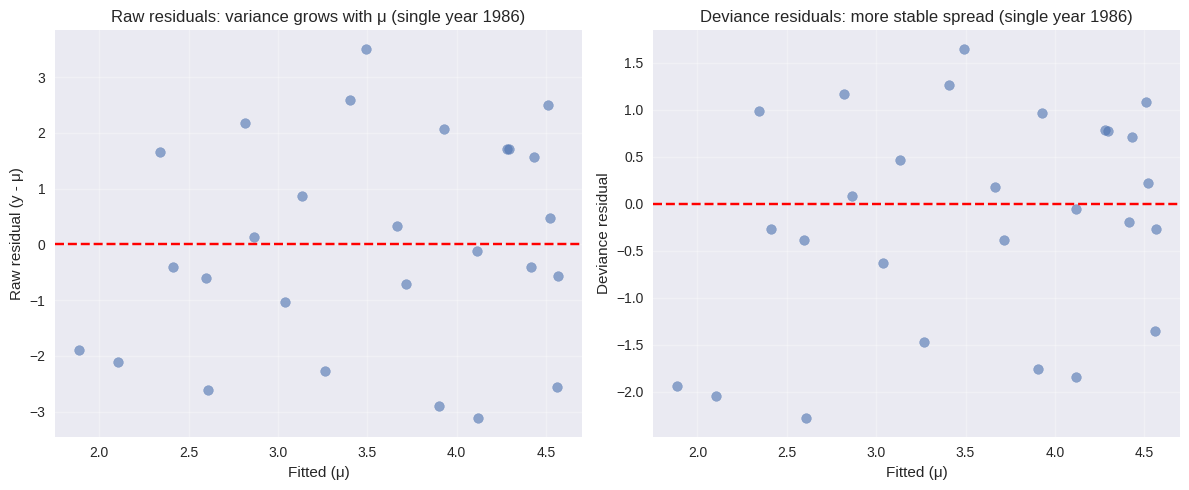

In [10]:
# Compare raw vs deviance residuals for a sample year
sample_year = sorted(models.keys())[len(models) // 2]
y = model_data[sample_year]['y']
mu = models[sample_year].predict(model_data[sample_year]['X'])

raw_res = y - mu
with np.errstate(divide='ignore', invalid='ignore'):
    dev_res = np.sign(y - mu) * np.sqrt(2 * (y * np.log(np.where(y > 0, y / (mu + 1e-10), 1)) - (y - mu)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(mu, raw_res, alpha=0.6)
axes[0].axhline(0, color='r', linestyle='--')
axes[0].set_xlabel('Fitted (μ)')
axes[0].set_ylabel('Raw residual (y - μ)')
axes[0].set_title(f'Raw residuals: variance grows with μ (single year {sample_year})')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(mu, dev_res, alpha=0.6)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Fitted (μ)')
axes[1].set_ylabel('Deviance residual')
axes[1].set_title(f'Deviance residuals: more stable spread (single year {sample_year})')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Model Diagnostics

**Top-left:** Residuals vs fitted—points roughly around zero; some spread is normal for counts. **Top-right:** Q-Q plot—deviation from the red line is common for Poisson. **Bottom-left:** Observed vs predicted (aggregated over all years). **Bottom-right:** Fitted curve with 95% prediction interval (aggregated over all years).

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


Diagnostics (all years): selected lambda = [[0.015848931924611134]]


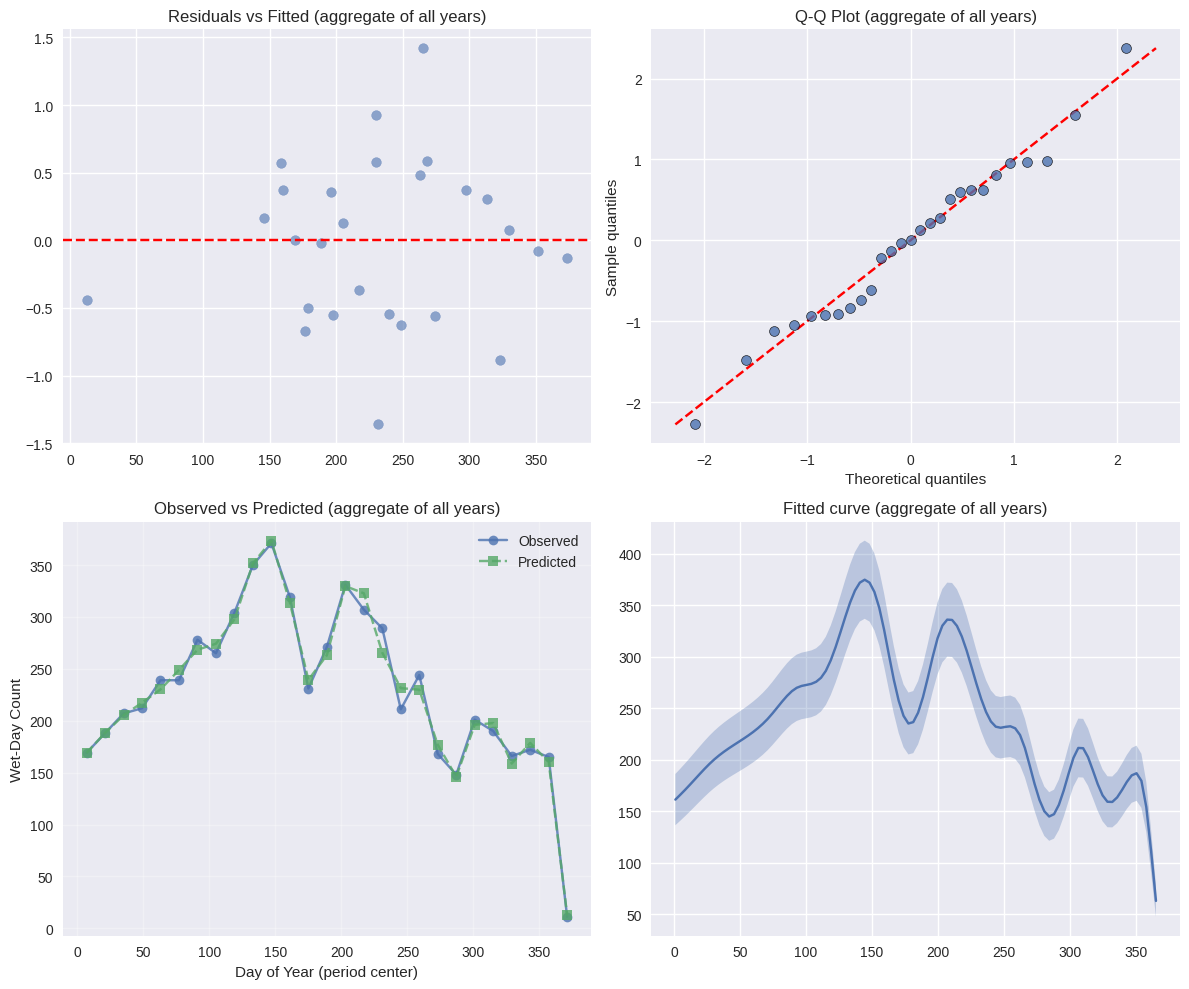

In [11]:
# Diagnostics: residuals, Q-Q, observed vs predicted (using data aggregated over all years)
from scipy.stats import norm
# Aggregate wet-day counts by period across all years
agg_all = wet_day_counts.groupby('period').agg({
    'day_of_year_approx': 'first',
    'wet_day_count': 'sum'
}).sort_values('day_of_year_approx')
X = agg_all[['day_of_year_approx']].values
y = agg_all['wet_day_count'].values
# Fit PoissonGAM on aggregated data
gam = PoissonGAM(s(0)).gridsearch(X, y)
print(f'Diagnostics (all years): selected lambda = {gam.lam}')
y_pred = gam.predict(X)
mu = y_pred
with np.errstate(divide='ignore', invalid='ignore'):
    # Compute deviance residuals for the Poisson model
    dev_res = np.sign(y - mu) * np.sqrt(2 * (y * np.log(np.where(y > 0, y / (mu + 1e-10), 1)) - (y - mu)))
# Standardize residuals; avoid div-by-zero when std=0
dev_std = np.std(dev_res)
std_res = dev_res / dev_std if dev_std > 1e-10 else dev_res

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0,0].scatter(y_pred, dev_res, alpha=0.6)
axes[0,0].axhline(0, color='r', linestyle='--')
axes[0,0].set_title('Residuals vs Fitted (aggregate of all years)')
# Q-Q plot: manual scatter for visible dots
qq_data = std_res[np.isfinite(std_res)]
if len(qq_data) >= 2:
    n = len(qq_data)
    sq = np.sort(qq_data)
    tq = norm.ppf((np.arange(1, n + 1) - 0.5) / n)
    axes[0,1].scatter(tq, sq, s=50, alpha=0.8, edgecolors='k', linewidths=0.5, zorder=2)
    lims = [min(tq.min(), sq.min()), max(tq.max(), sq.max())]
    axes[0,1].plot(lims, lims, 'r--', zorder=1)
    axes[0,1].set_xlabel('Theoretical quantiles')
    axes[0,1].set_ylabel('Sample quantiles')
else:
    axes[0,1].text(0.5, 0.5, 'Too few valid residuals for Q-Q plot', ha='center', va='center', transform=axes[0,1].transAxes)
axes[0,1].set_title('Q-Q Plot (aggregate of all years)')
axes[1,0].plot(X.flatten(), y, 'o-', color='C0', label='Observed', alpha=0.8)
axes[1,0].plot(X.flatten(), y_pred, 's--', color='C1', label='Predicted', alpha=0.8)
axes[1,0].set_xlabel('Day of Year (period center)')
axes[1,0].set_ylabel('Wet-Day Count')
axes[1,0].set_title('Observed vs Predicted (aggregate of all years)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)
Xp = np.linspace(1, 365, 100).reshape(-1, 1)
yp = gam.predict(Xp)
axes[1,1].plot(Xp, yp)
axes[1,1].fill_between(Xp.flatten(), np.maximum(0, yp - 1.96*np.sqrt(yp)), yp + 1.96*np.sqrt(yp), alpha=0.3)
axes[1,1].set_title('Fitted curve (aggregate of all years)')
plt.tight_layout()
plt.show()

## Interpretation
**Log link**: log(μ) = f(day) → μ = exp(f). Peaks = wetter periods. **When to use PoissonGAM**: count data, mean ≈ var. **Alternatives**: NegativeBinomialGAM (overdispersion), GammaGAM (amounts), LogisticGAM (binary).